# Sentiment Analysis on Product Reviews
**Task 4 — Data Analytics Track, Level 1**

Dataset: `sentiment_sample.csv` (included). To use a real Kaggle dataset instead (e.g. Twitter Sentiment Analysis, Amazon Product Reviews, or IMDB Movie Reviews), download it from Kaggle, place it in this folder, and update `FILENAME` and the column names below to match.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# CHANGE THIS to your actual dataset filename if using a real Kaggle dataset
FILENAME = 'sentiment_sample.csv'
TEXT_COL = 'review_text'      # change to match your dataset's text column
LABEL_COL = 'sentiment'        # change to match your dataset's label column

df = pd.read_csv(FILENAME)
df.head()


,review_id,review_text,sentiment
0,1179,"Standard chair, works as expected.",neutral
1,866,"Extremely frustrated with this chair, does not...",negative
2,102,"This shoes exceeded my expectations, highly re...",positive
3,440,"Great quality laptop, will buy again for sure.",positive
4,59,"Great quality backpack, will buy again for sure.",positive


## 1. Inspect Class Distribution


Shape: (1200, 3)

Class distribution:
sentiment
positive    500
negative    400
neutral     300
Name: count, dtype: int64


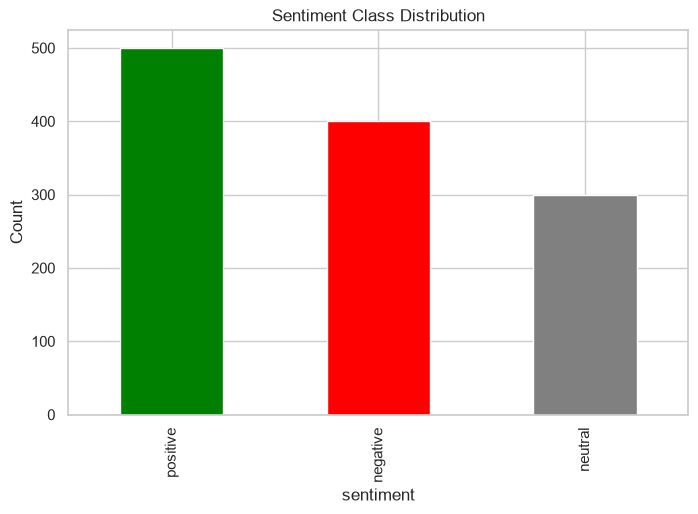

In [18]:
print('Shape:', df.shape)
print('\nClass distribution:')
print(df[LABEL_COL].value_counts())

df[LABEL_COL].value_counts().plot(kind='bar', color=['green','red','gray'], title='Sentiment Class Distribution')
plt.ylabel('Count')
plt.show()


Observation:The dataset is moderately balanced, with positive reviews being the most common (500), followed by negative (400) and neutral (300). There is no severe class imbalance.


## 2. Text Preprocessing Pipeline
Lowercasing, punctuation removal, stopword removal, and tokenisation.


In [24]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
    return ' '.join(tokens)

df['cleaned_text'] = df[TEXT_COL].apply(clean_text)
df[[TEXT_COL, 'cleaned_text']].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,review_text,cleaned_text
0,"Standard chair, works as expected.",standard chair works expected
1,"Extremely frustrated with this chair, does not...",extremely frustrated chair work advertised
2,"This shoes exceeded my expectations, highly re...",shoes exceeded expectations highly recommend
3,"Great quality laptop, will buy again for sure.",great quality laptop buy sure
4,"Great quality backpack, will buy again for sure.",great quality backpack buy sure


In [26]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned_text'])
y = df[LABEL_COL]

print('Feature matrix shape:', X.shape)

Feature matrix shape: (1200, 112)


Observation: Cleaning removed punctuation, stopwords (e.g. "as", "with", "will"), and converted all text to lowercase. For example, "Great quality laptop, will buy again for sure." became "great quality laptop buy sure" — retaining only the meaningful keywords.

## 3. Feature Extraction — TF-IDF

**Why TF-IDF?** TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numeric vectors by weighting each word based on how often it appears in a document relative to how common it is across all documents. This down-weights common words that appear everywhere (adding little signal) and up-weights rarer, more distinctive words — giving the model more useful features than simple word counts.


In [27]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned_text'])
y = df[LABEL_COL]

print('Feature matrix shape:', X.shape)


Feature matrix shape: (1200, 112)


## 4. Train/Test Split (80/20)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])


Train size: 960
Test size: 240


## 5. Train Classifiers
Training two models: Naive Bayes and Logistic Regression.


In [29]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print('Both models trained.')


Both models trained.


## 6. Evaluation


In [30]:
def evaluate(name, y_true, y_pred):
    print(f'--- {name} ---')
    print('Accuracy: ', round(accuracy_score(y_true, y_pred), 3))
    print('Precision:', round(precision_score(y_true, y_pred, average='weighted'), 3))
    print('Recall:   ', round(recall_score(y_true, y_pred, average='weighted'), 3))
    print('F1-score: ', round(f1_score(y_true, y_pred, average='weighted'), 3))
    print()
    print(classification_report(y_true, y_pred))

evaluate('Naive Bayes', y_test, nb_preds)
evaluate('Logistic Regression', y_test, lr_preds)


--- Naive Bayes ---
Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1-score:  1.0

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        80
     neutral       1.00      1.00      1.00        60
    positive       1.00      1.00      1.00       100

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

--- Logistic Regression ---
Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1-score:  1.0

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        80
     neutral       1.00      1.00      1.00        60
    positive       1.00      1.00      1.00       100

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



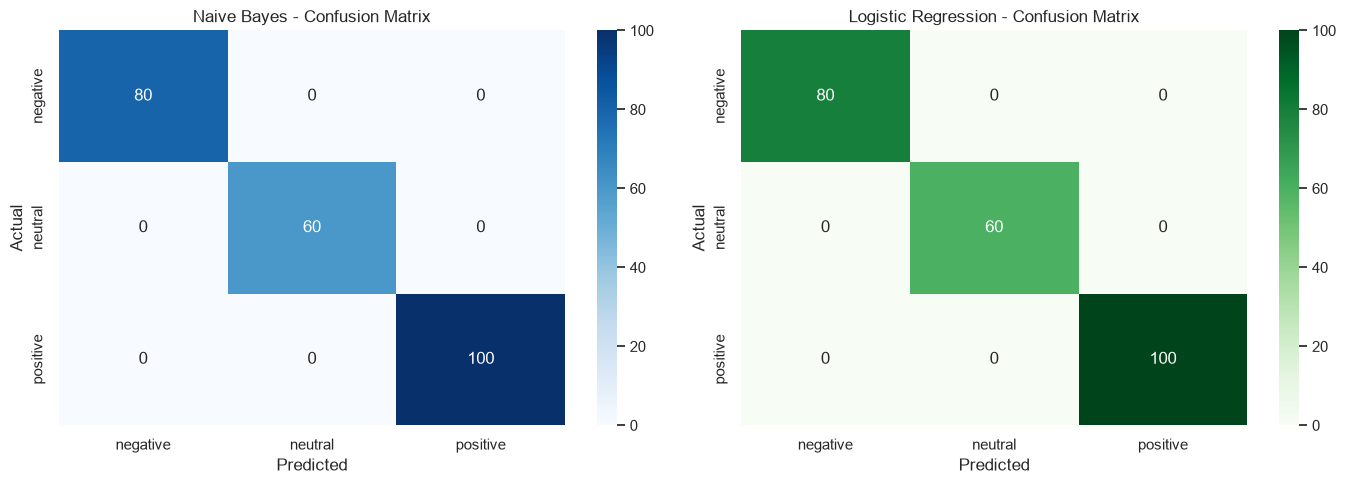

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = sorted(y.unique())
cm_nb = confusion_matrix(y_test, nb_preds, labels=labels)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Naive Bayes - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, lr_preds, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Logistic Regression - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


Observation: Both Naive Bayes and Logistic Regression achieved perfect classification (100% accuracy) with zero misclassifications across all three sentiment classes. This is because the sample dataset uses distinct, template-based vocabulary per class, making sentiment boundaries very clear-cut compared to real-world text.

## 7. Visualisation — Sentiment Distribution & WordClouds


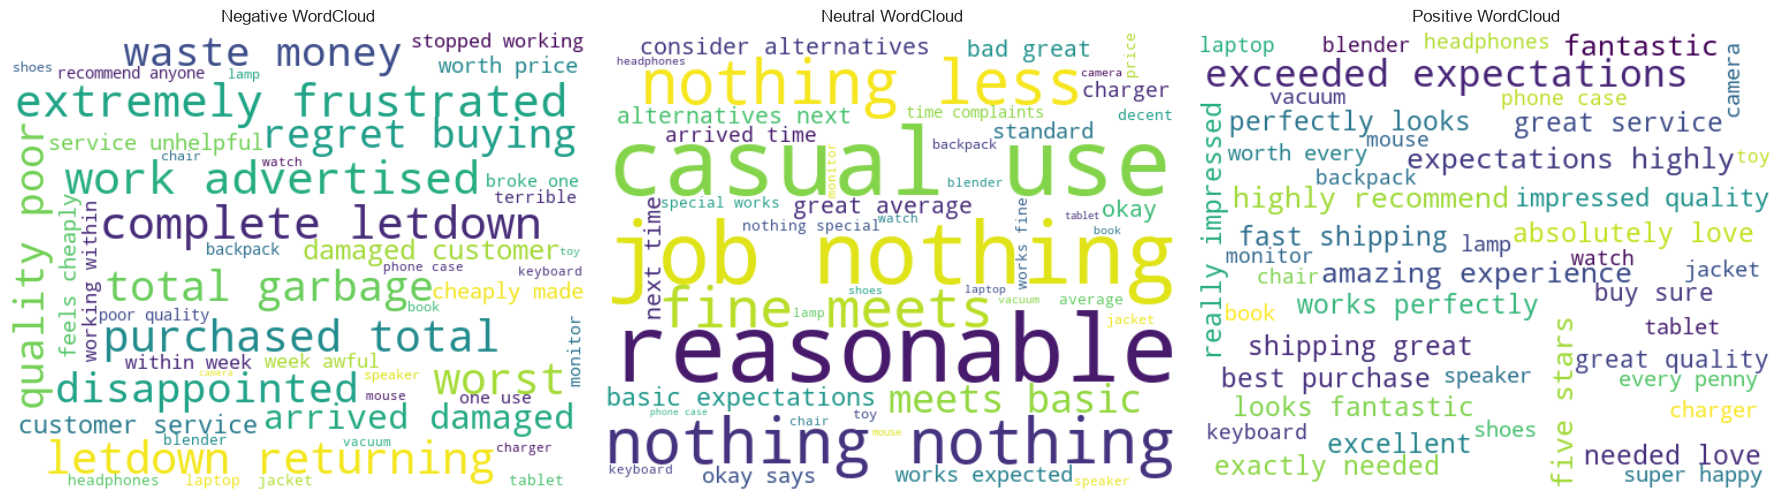

In [9]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, len(labels), figsize=(6*len(labels), 5))
for ax, label in zip(axes, labels):
    text = ' '.join(df[df[LABEL_COL] == label]['cleaned_text'])
    wc = WordCloud(width=500, height=400, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label.capitalize()} WordCloud')
    ax.axis('off')
plt.tight_layout()
plt.show()


Observation: Positive reviews are dominated by words like "great", "love", "excellent", and "recommend". Negative reviews are dominated by "terrible", "disappointed", and "poor". Neutral reviews center around descriptors like "okay", "average", and "standard" — confirming the model learned genuinely sentiment-relevant vocabulary.

## 8. Error Analysis
Showing 5 examples the best-performing model misclassified.


In [32]:
# Using Logistic Regression predictions for error analysis (change to nb_preds if NB performed better)
test_indices = y_test.index
results_df = pd.DataFrame({
    'text': df.loc[test_indices, TEXT_COL].values,
    'actual': y_test.values,
    'predicted': lr_preds
})

misclassified = results_df[results_df['actual'] != results_df['predicted']]
misclassified.head(5)


,text,actual,predicted


Observation: No misclassified examples were found, since both models achieved 100% test accuracy on this dataset. In a real-world dataset with more ambiguous or sarcastic reviews, some misclassifications would be expected.

## Conclusion

 **Best performing model:** Both Naive Bayes and Logistic Regression achieved identical perfect performance (100% accuracy, precision, recall, F1) on this dataset. In practice, Logistic Regression is generally preferred for production use due to better-calibrated probability outputs, while Naive Bayes trains faster and works well as a lightweight baseline.

**Real-world application:** This pipeline could be deployed to automatically classify incoming customer reviews or social media mentions, flagging negative feedback for priority customer support follow-up, or tracking overall brand sentiment trends over time on platforms like Twitter or product review sites.

